In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
import seaborn as sns
from scipy.signal import butter, filtfilt, iirnotch, find_peaks
import pywt
from tqdm import tqdm
import neurokit2 as nk

## 1. Reading ECG (Electrocardiogram) Signals
first of all, we need to read the ECG signals from a file. We can use the `wfdb` library to read the ECG data

In [2]:
# patien_id with brugada type 2: 460919
# patiend_id with brugada type 1: 419960
# patiend_id normal: 251972
patient_id = '292666'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

In [3]:
signals = record.p_signal
lead_names = record.sig_name
sampling_freq = record.fs
duration = len(signals) / sampling_freq

## 2. Preprocessing the ECG Signals

### 2.1 Butter bandpass Filter

In [4]:
def butter_bandpass(
    lowcut: float,
    highcut: float, 
    fs: float, 
    order: int = 4
  ):
  nyquist = 0.5 * fs
  low = lowcut / nyquist
  high = highcut / nyquist

  b, a = butter(order, [low, high], btype='band')
  return b, a

def butter_bandpass_filter(
    signal, 
    lowcut: float = 0.5, 
    highcut: float = 40.0, 
    fs: float = 100, 
    order: int = 4
  ):
  b, a = butter_bandpass(lowcut, highcut, fs, order=order)
  y = filtfilt(b, a, signal)
  return y

In [5]:
clean_bpf = np.zeros_like(signals)
for lead_index in range(signals.shape[1]):
  lead = signals[:, lead_index]
  lead = butter_bandpass_filter(lead, fs=sampling_freq)
  
  clean_bpf[:, lead_index] = lead

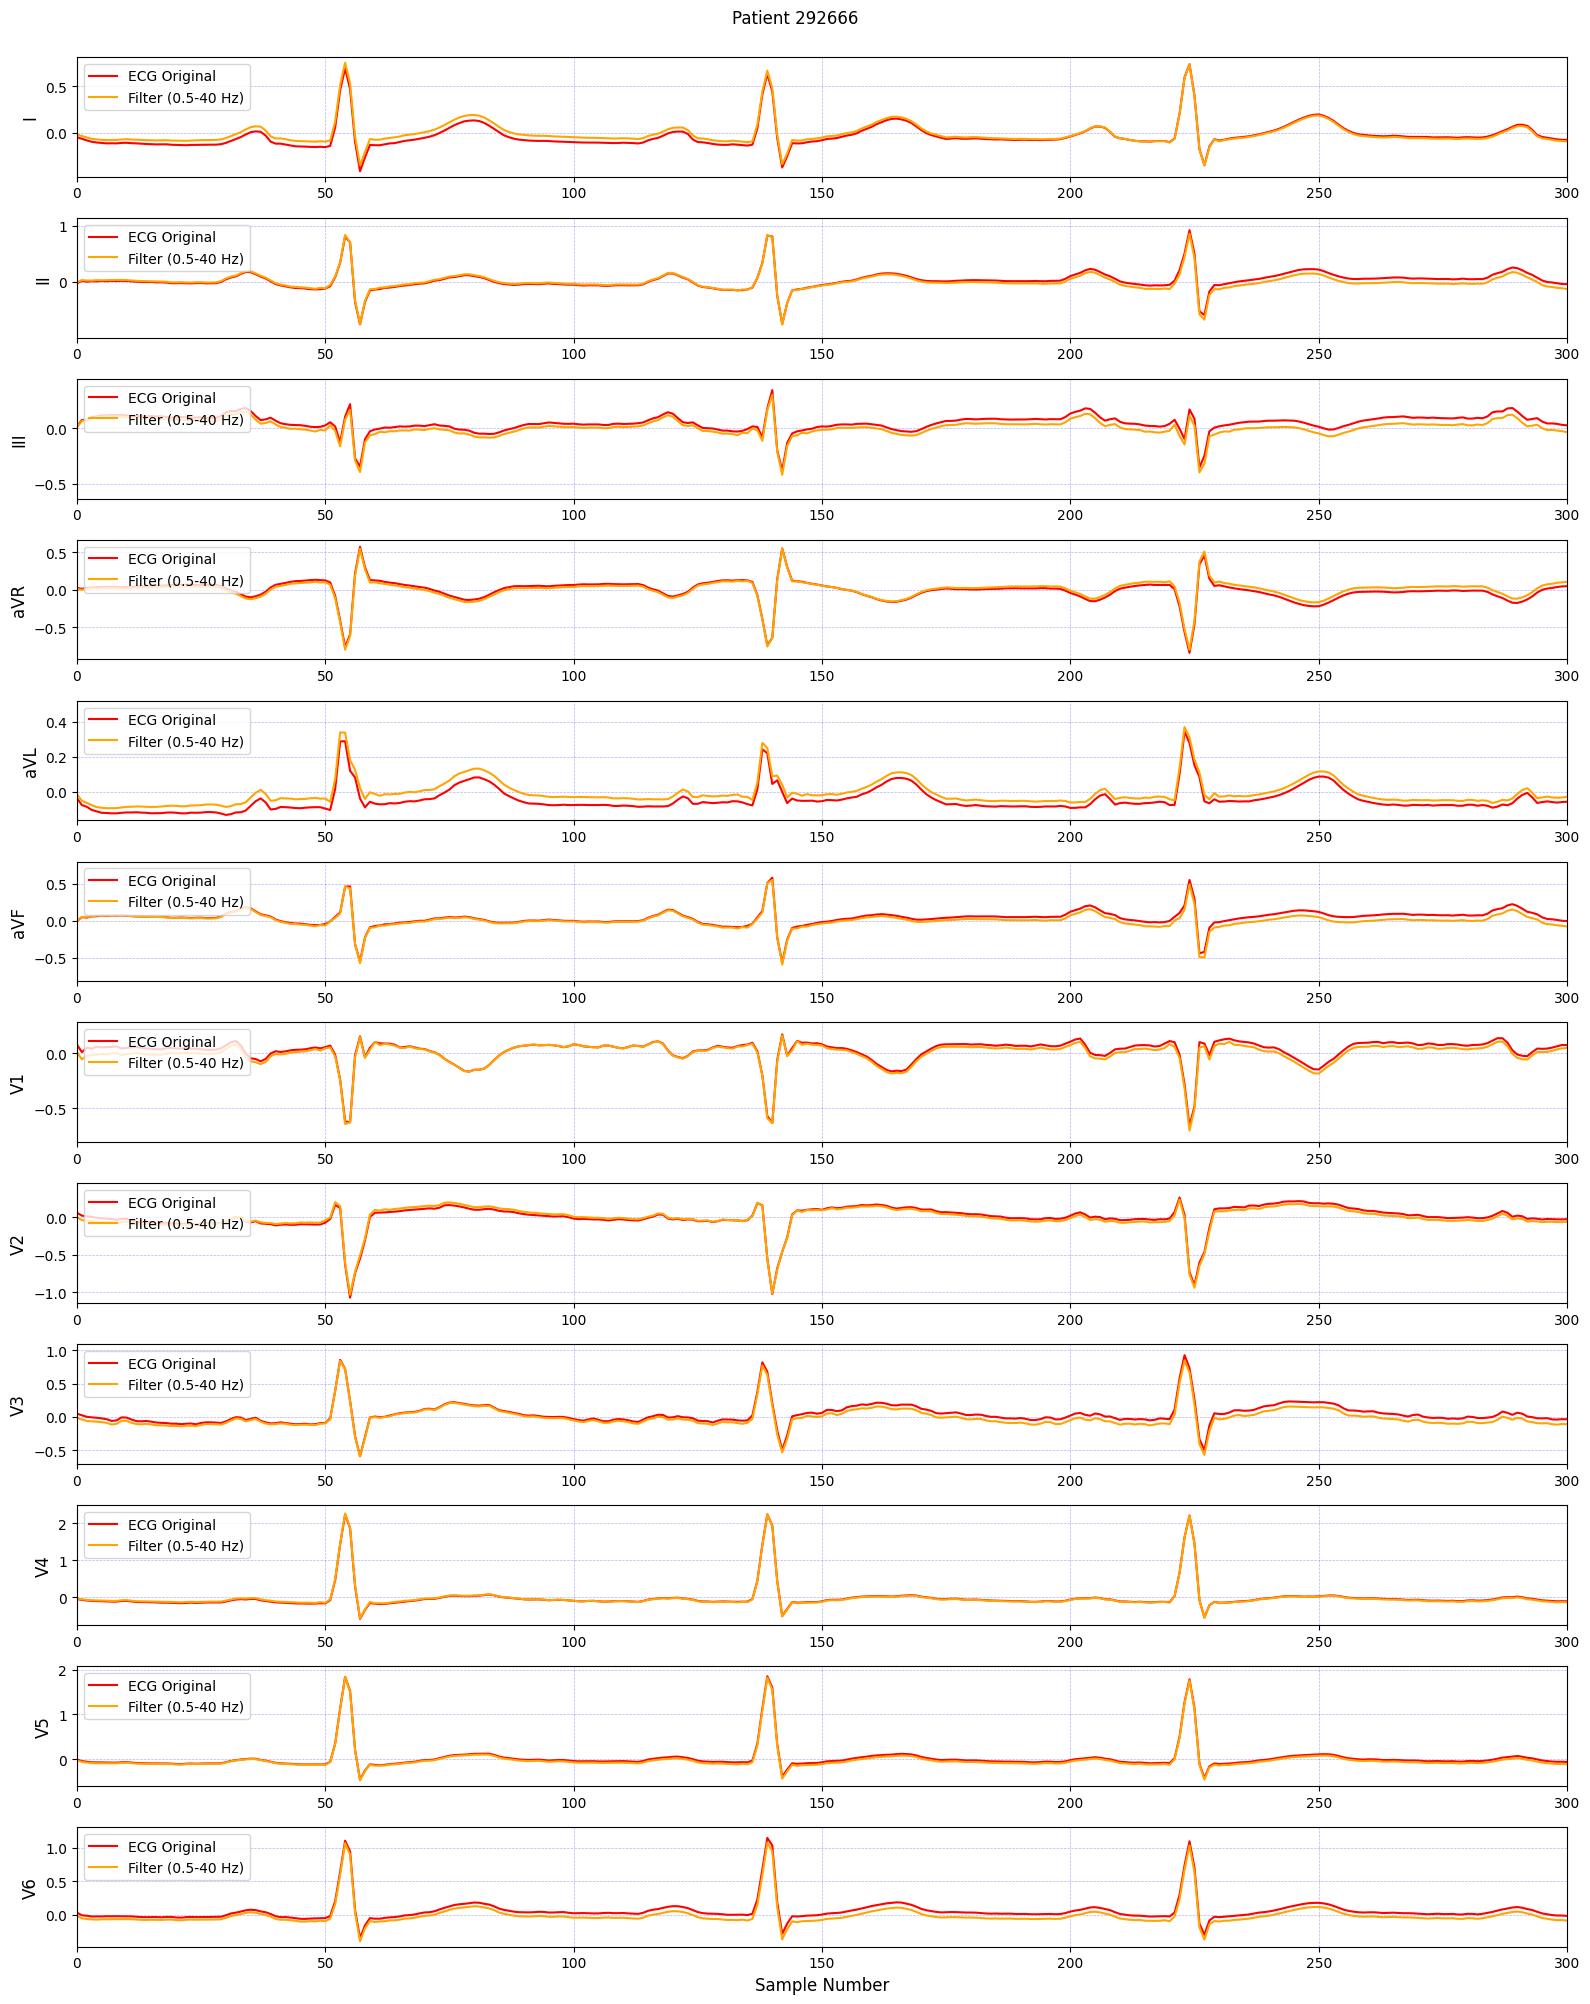

In [6]:
fig, axes = plt.subplots(12, 1, figsize=(16, 20))

for i, lead_name in enumerate(lead_names):
  axes[i].plot(signals[:, i], linewidth=1.5, color='red')
  axes[i].plot(clean_bpf[:, i], linewidth=1.5, color='orange')
  axes[i].set_ylabel(lead_name, fontsize=12, fontweight='medium')
  axes[i].legend(['ECG Original', 'Filter (0.5-40 Hz)'], loc="upper left")
  axes[i].grid(True, linestyle='--', linewidth=0.5, color='blue', alpha=0.3)

  # focusing waveform at specific time (0, duration)
  axes[i].set_xlim(0, 300) 

plt.suptitle(f'Patient {patient_id}', y=1)
plt.xlabel('Sample Number', fontsize=12)
plt.tight_layout()
plt.show()


### 2.2 Baseline Wander Removal

In [7]:
def butter_highpass(
  cutoff: float,
  fs: float,
  order: int = 5
):
  nyquist = 0.5 * fs
  b, a = butter(order, cutoff / nyquist, btype='high')
  return b, a


def remove_baseline_wander(signal, fs: float = 100.0):
  b, a = butter_highpass(0.5, fs)
  return filtfilt(b, a, signal)

In [8]:
clean_baseline_wonder = np.zeros_like(signals)
for lead_index in range(signals.shape[1]):
  lead = signals[:, lead_index]
  lead = remove_baseline_wander(lead, fs=sampling_freq)
  
  clean_baseline_wonder[:, lead_index] = lead

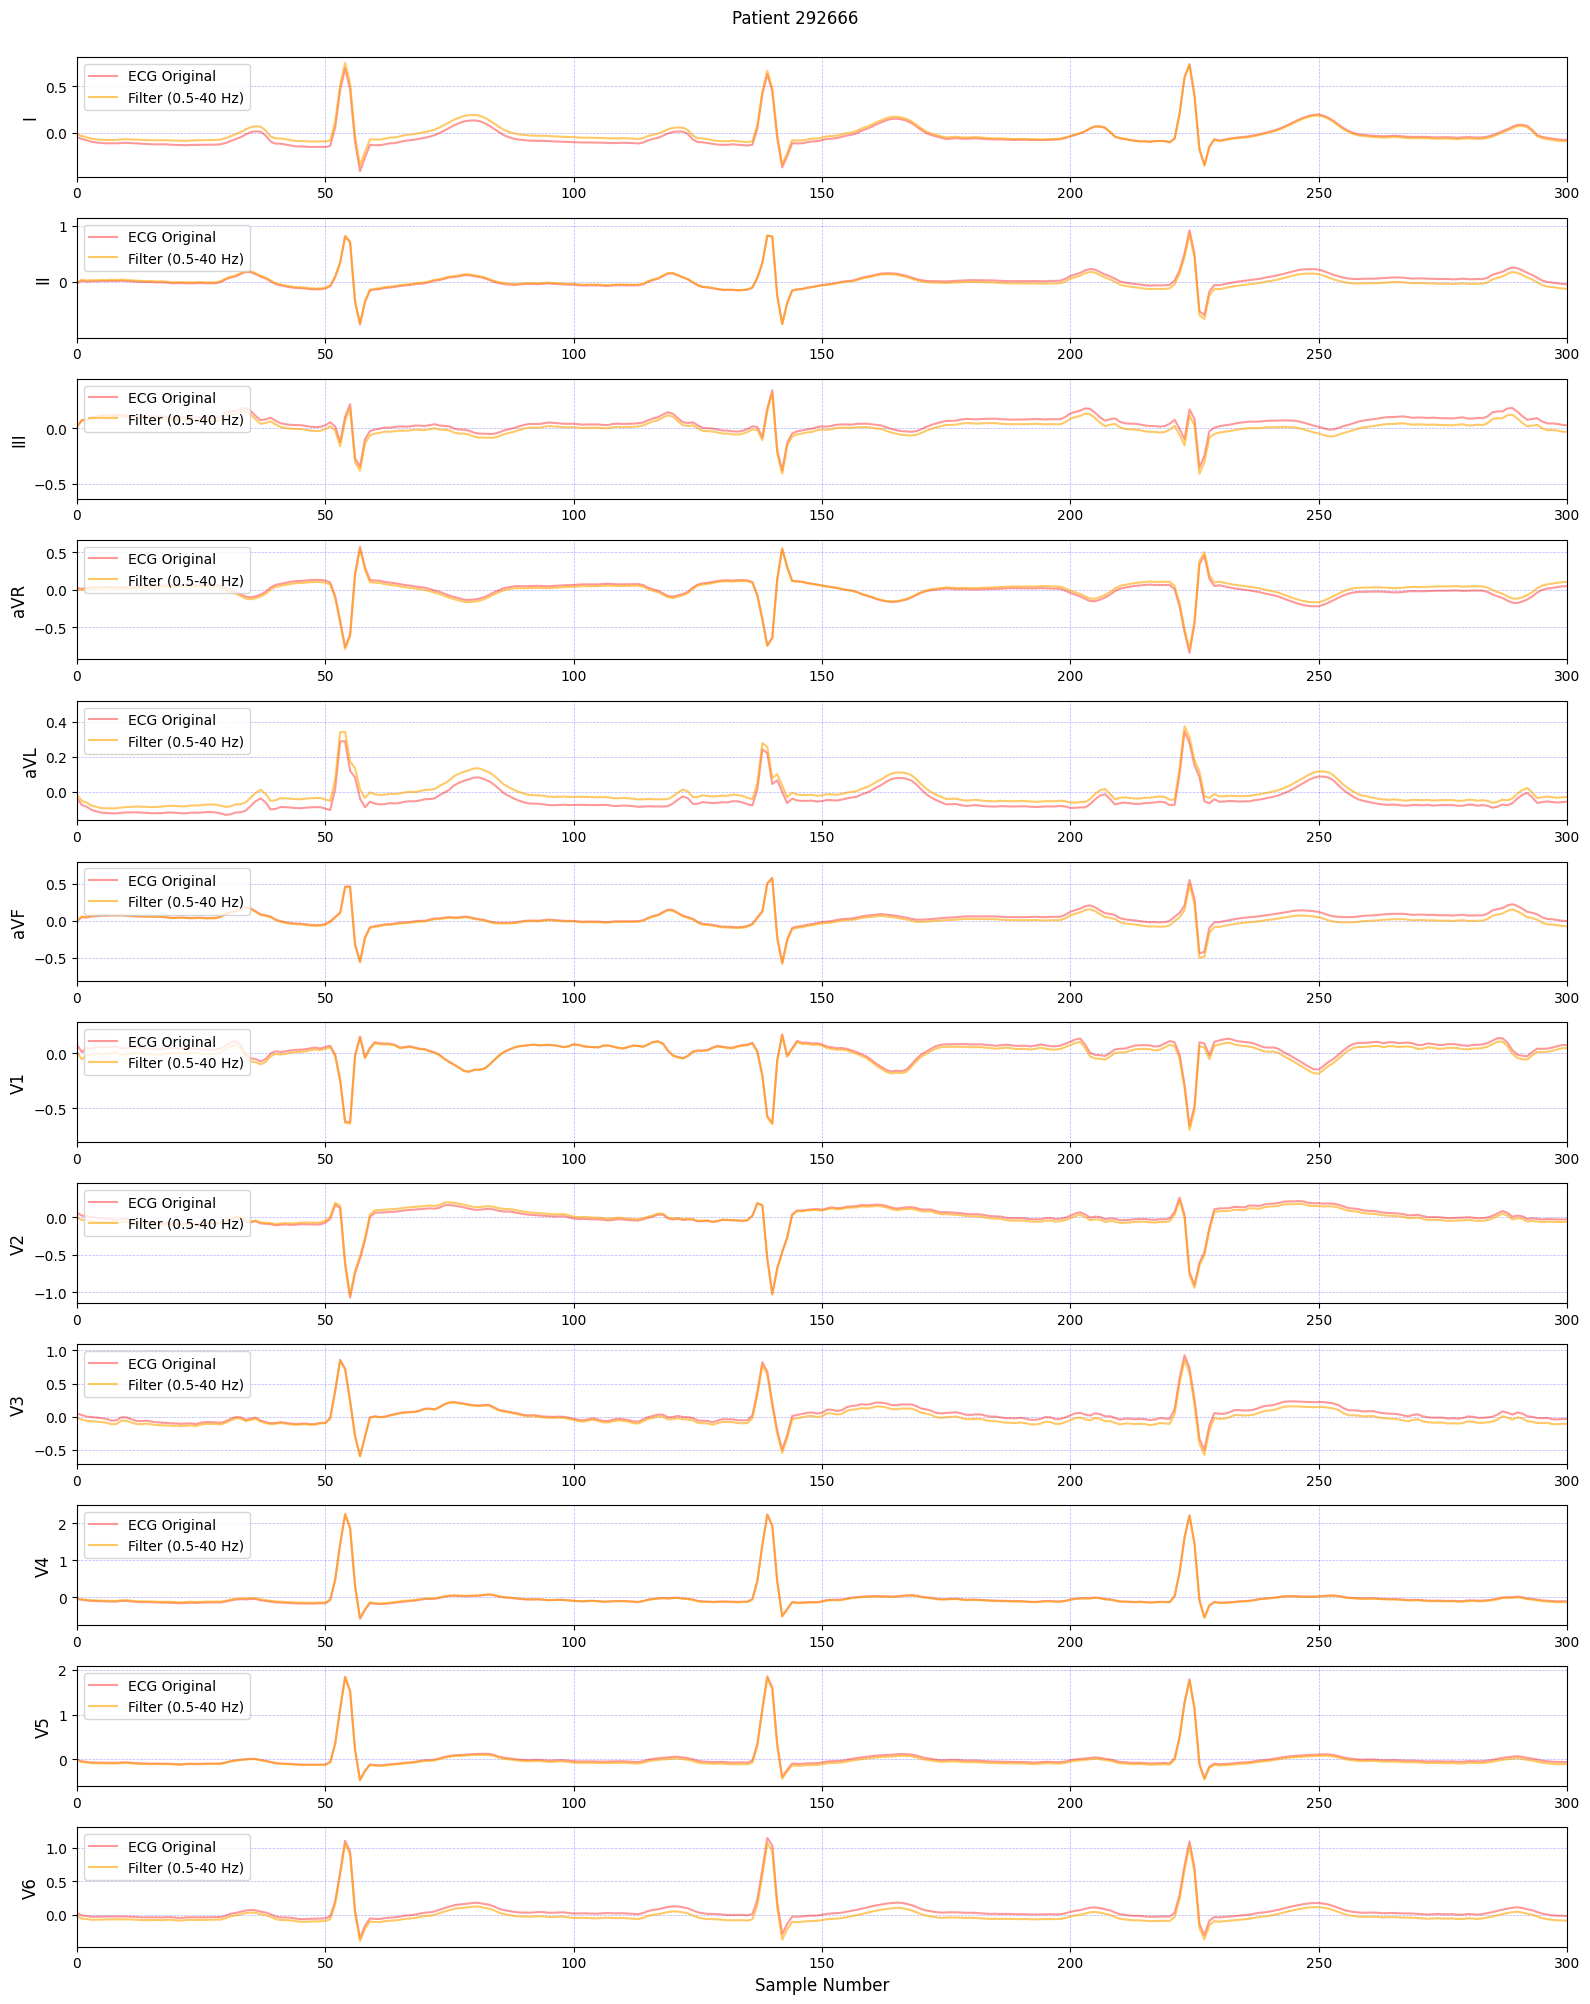

In [9]:
fig, axes = plt.subplots(12, 1, figsize=(16, 20))

for i, lead_name in enumerate(lead_names):
  axes[i].plot(signals[:, i], linewidth=1.5, color='red', alpha=0.4)
  axes[i].plot(clean_baseline_wonder[:, i], linewidth=1.5, color='orange', alpha=0.6)
  axes[i].set_ylabel(lead_name, fontsize=12, fontweight='medium')
  axes[i].legend(['ECG Original', 'Filter (0.5-40 Hz)'], loc="upper left")
  axes[i].grid(True, linestyle='--', linewidth=0.5, color='blue', alpha=0.3)

  # focusing waveform at specific time (0, duration)
  axes[i].set_xlim(0, 300) 

plt.suptitle(f'Patient {patient_id}', y=1)
plt.xlabel('Sample Number', fontsize=12)
plt.tight_layout()
plt.show()


### 2.3 Wavelet Denoising


In [10]:
def wavelet_denoise(signal, wavelet='db4', level=4, threshold_scale=1.0):
  # Decompose
  coeffs = pywt.wavedec(signal, wavelet, level=level)
  
  # Calculate threshold
  sigma = np.median(np.abs(coeffs[-1])) / 0.6745
  threshold = threshold_scale * sigma * np.sqrt(2 * np.log(len(signal)))
  
  # Threshold (keep approximation, threshold details)
  coeffs_thresh = coeffs.copy()
  for i in range(1, len(coeffs)):
    coeffs_thresh[i] = pywt.threshold(coeffs[i], threshold, mode='soft')
  
  # Reconstruct
  denoised = pywt.waverec(coeffs_thresh, wavelet)
  
  # Adjust length
  if len(denoised) > len(signal):
    denoised = denoised[:len(signal)]
  
  return denoised

### 2.4 Z-score Normalization

In [11]:
def zscore_normalise(signal: np.ndarray):
  """Z-score normalize signal"""
  mean = np.mean(signal)
  std = np.std(signal)
  if std == 0:
    return signal
  return (signal - mean) / std

### 2.5 Preprocessing Pipeline

In [12]:
def preprocess_record(signal: np.ndarray, fs: float = 100):
  clean = np.zeros_like(signal)

  for lead_index in range(signal.shape[1]):
    lead = signal[:, lead_index]
    lead = remove_baseline_wander(lead, fs=fs)
    lead = butter_bandpass_filter(lead, lowcut=0.5, highcut=40.0, fs=fs)
    lead = wavelet_denoise(lead, wavelet='db4', level=4, threshold_scale=1.0)
    lead = zscore_normalise(lead)

    clean[:, lead_index] = lead

  return clean


In [13]:
def preprocess_dataset(data: np.ndarray, fs: float = 100): 
  signals_clean = np.zeros_like(data)
  for i in tqdm(range(data.shape[0])):
    signals_clean[i] = preprocess_record(data[i], fs)
  return signals_clean

signals_clean = preprocess_record(signals)

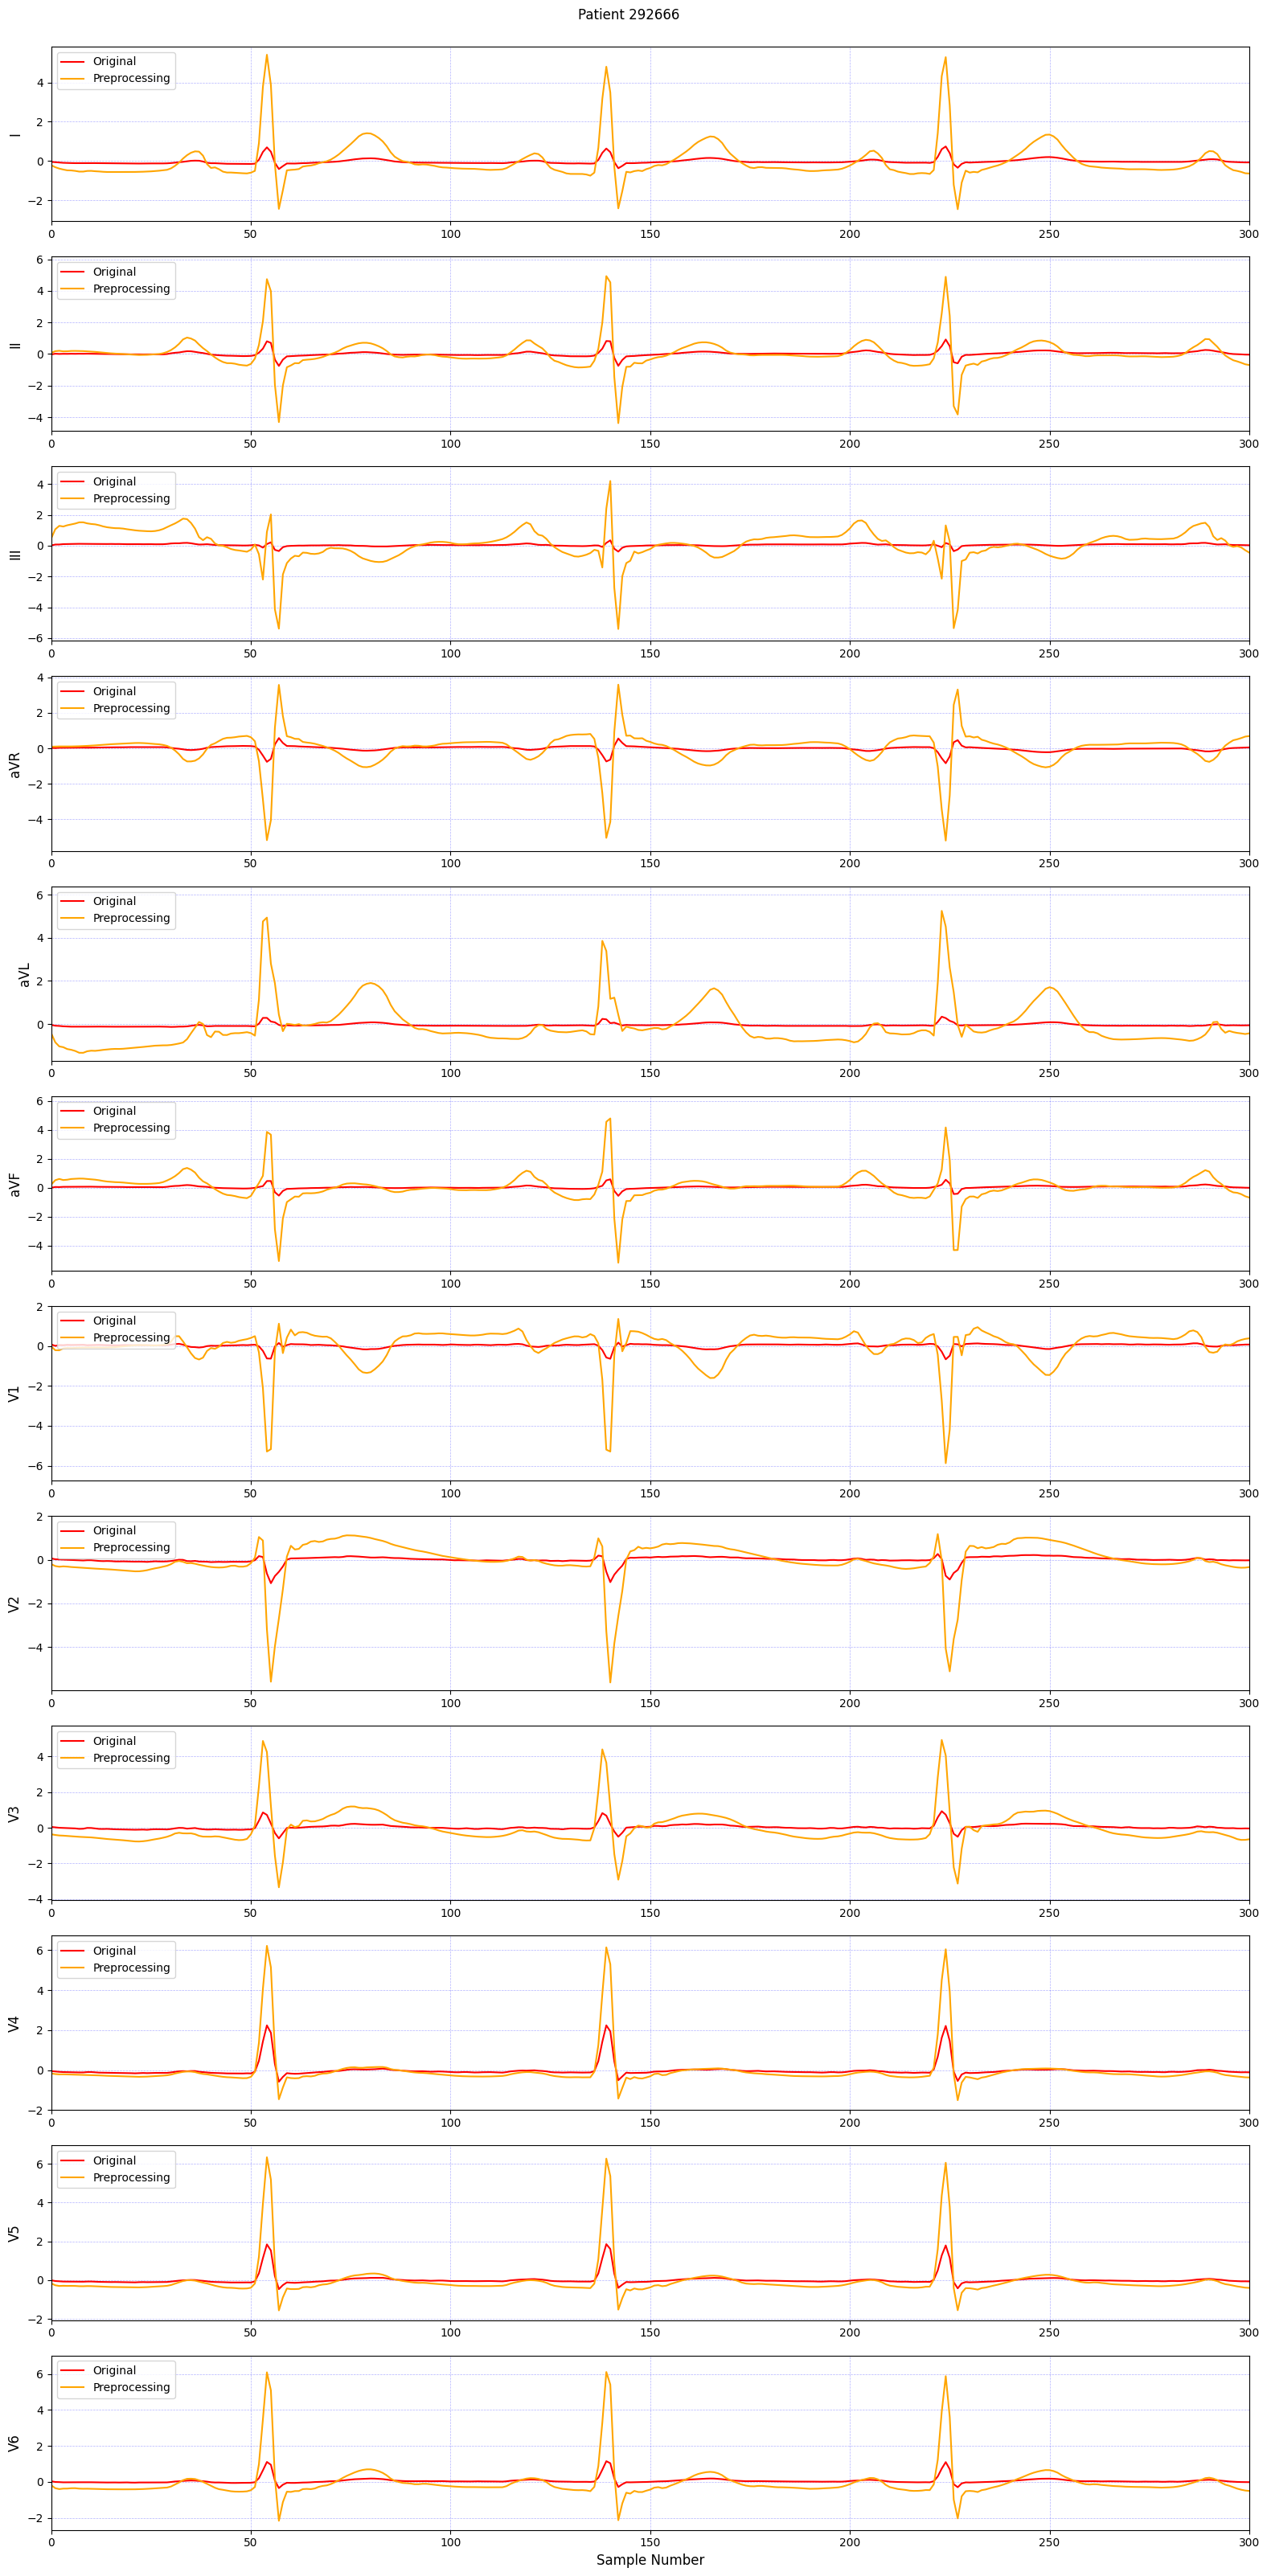

In [14]:
fig, axes = plt.subplots(12, 1, figsize=(16, 32))

for i, lead_name in enumerate(lead_names):
  axes[i].plot(signals[:, i], linewidth=1.5, color='red')
  axes[i].plot(signals_clean[:, i], linewidth=1.5, color='orange')
  axes[i].set_ylabel(lead_name, fontsize=12, fontweight='medium')
  axes[i].legend(['Original', 'Preprocessing'], loc="upper left")
  axes[i].grid(True, linestyle='--', linewidth=0.5, color='blue', alpha=0.3)

  # focusing waveform at specific time (0, duration)
  axes[i].set_xlim(0, 300) 

plt.suptitle(f'Patient {patient_id}', y=1)
plt.xlabel('Sample Number', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Feature Extraction


### 3.1 Time Domain Features

In [15]:
from scipy.stats import skew, kurtosis as scipy_curtosis

def time_domain_features(signal: np.ndarray):
  features_list = []

  for i in range(signal.shape[1]):
    lead = signal[:, i]

    features_list.extend([
      lead.mean(),
      lead.std(),
      np.sqrt(np.mean(lead ** 2)),
    ])

  return np.array(features_list, dtype=np.float32)

In [16]:
time_domain = time_domain_features(signals_clean)
print(f"Min max time_domain features: {time_domain}")
print(f"Min max time_domain features: {len(time_domain)}")

Min max time_domain features: [ 8.8817840e-18  1.0000000e+00  1.0000000e+00  7.4014872e-18
  1.0000000e+00  1.0000000e+00  1.7763568e-17  1.0000000e+00
  1.0000000e+00 -7.4014872e-18  1.0000000e+00  1.0000000e+00
  1.4802974e-18  1.0000000e+00  1.0000000e+00  2.2204460e-18
  1.0000000e+00  1.0000000e+00  1.4802974e-17  1.0000000e+00
  1.0000000e+00  0.0000000e+00  1.0000000e+00  1.0000000e+00
  5.9211896e-18  1.0000000e+00  1.0000000e+00 -5.1810408e-18
  1.0000000e+00  1.0000000e+00 -5.9211896e-18  1.0000000e+00
  1.0000000e+00 -7.4014872e-18  1.0000000e+00  1.0000000e+00]
Min max time_domain features: 36


### 3.2 Detect R-peaks

In [17]:
def detect_r_peaks(lead: np.ndarray, fs: int = 100):
  ecg = lead.copy()

  ecg_f = butter_bandpass_filter(ecg, lowcut=0.5, highcut=40.0, fs=fs)
  ecg_sq = ecg_f ** 2

  thresh = np.mean(ecg_sq) + 0.5 * np.std(ecg_sq)

  min_dist = int(0.4 * fs)

  peaks, _ = find_peaks(
      ecg_sq,
      height=thresh,
      distance=min_dist
  )

  return peaks

In [18]:
lead = signals_clean[:, 1]
r_peaks = detect_r_peaks(lead, fs=100)

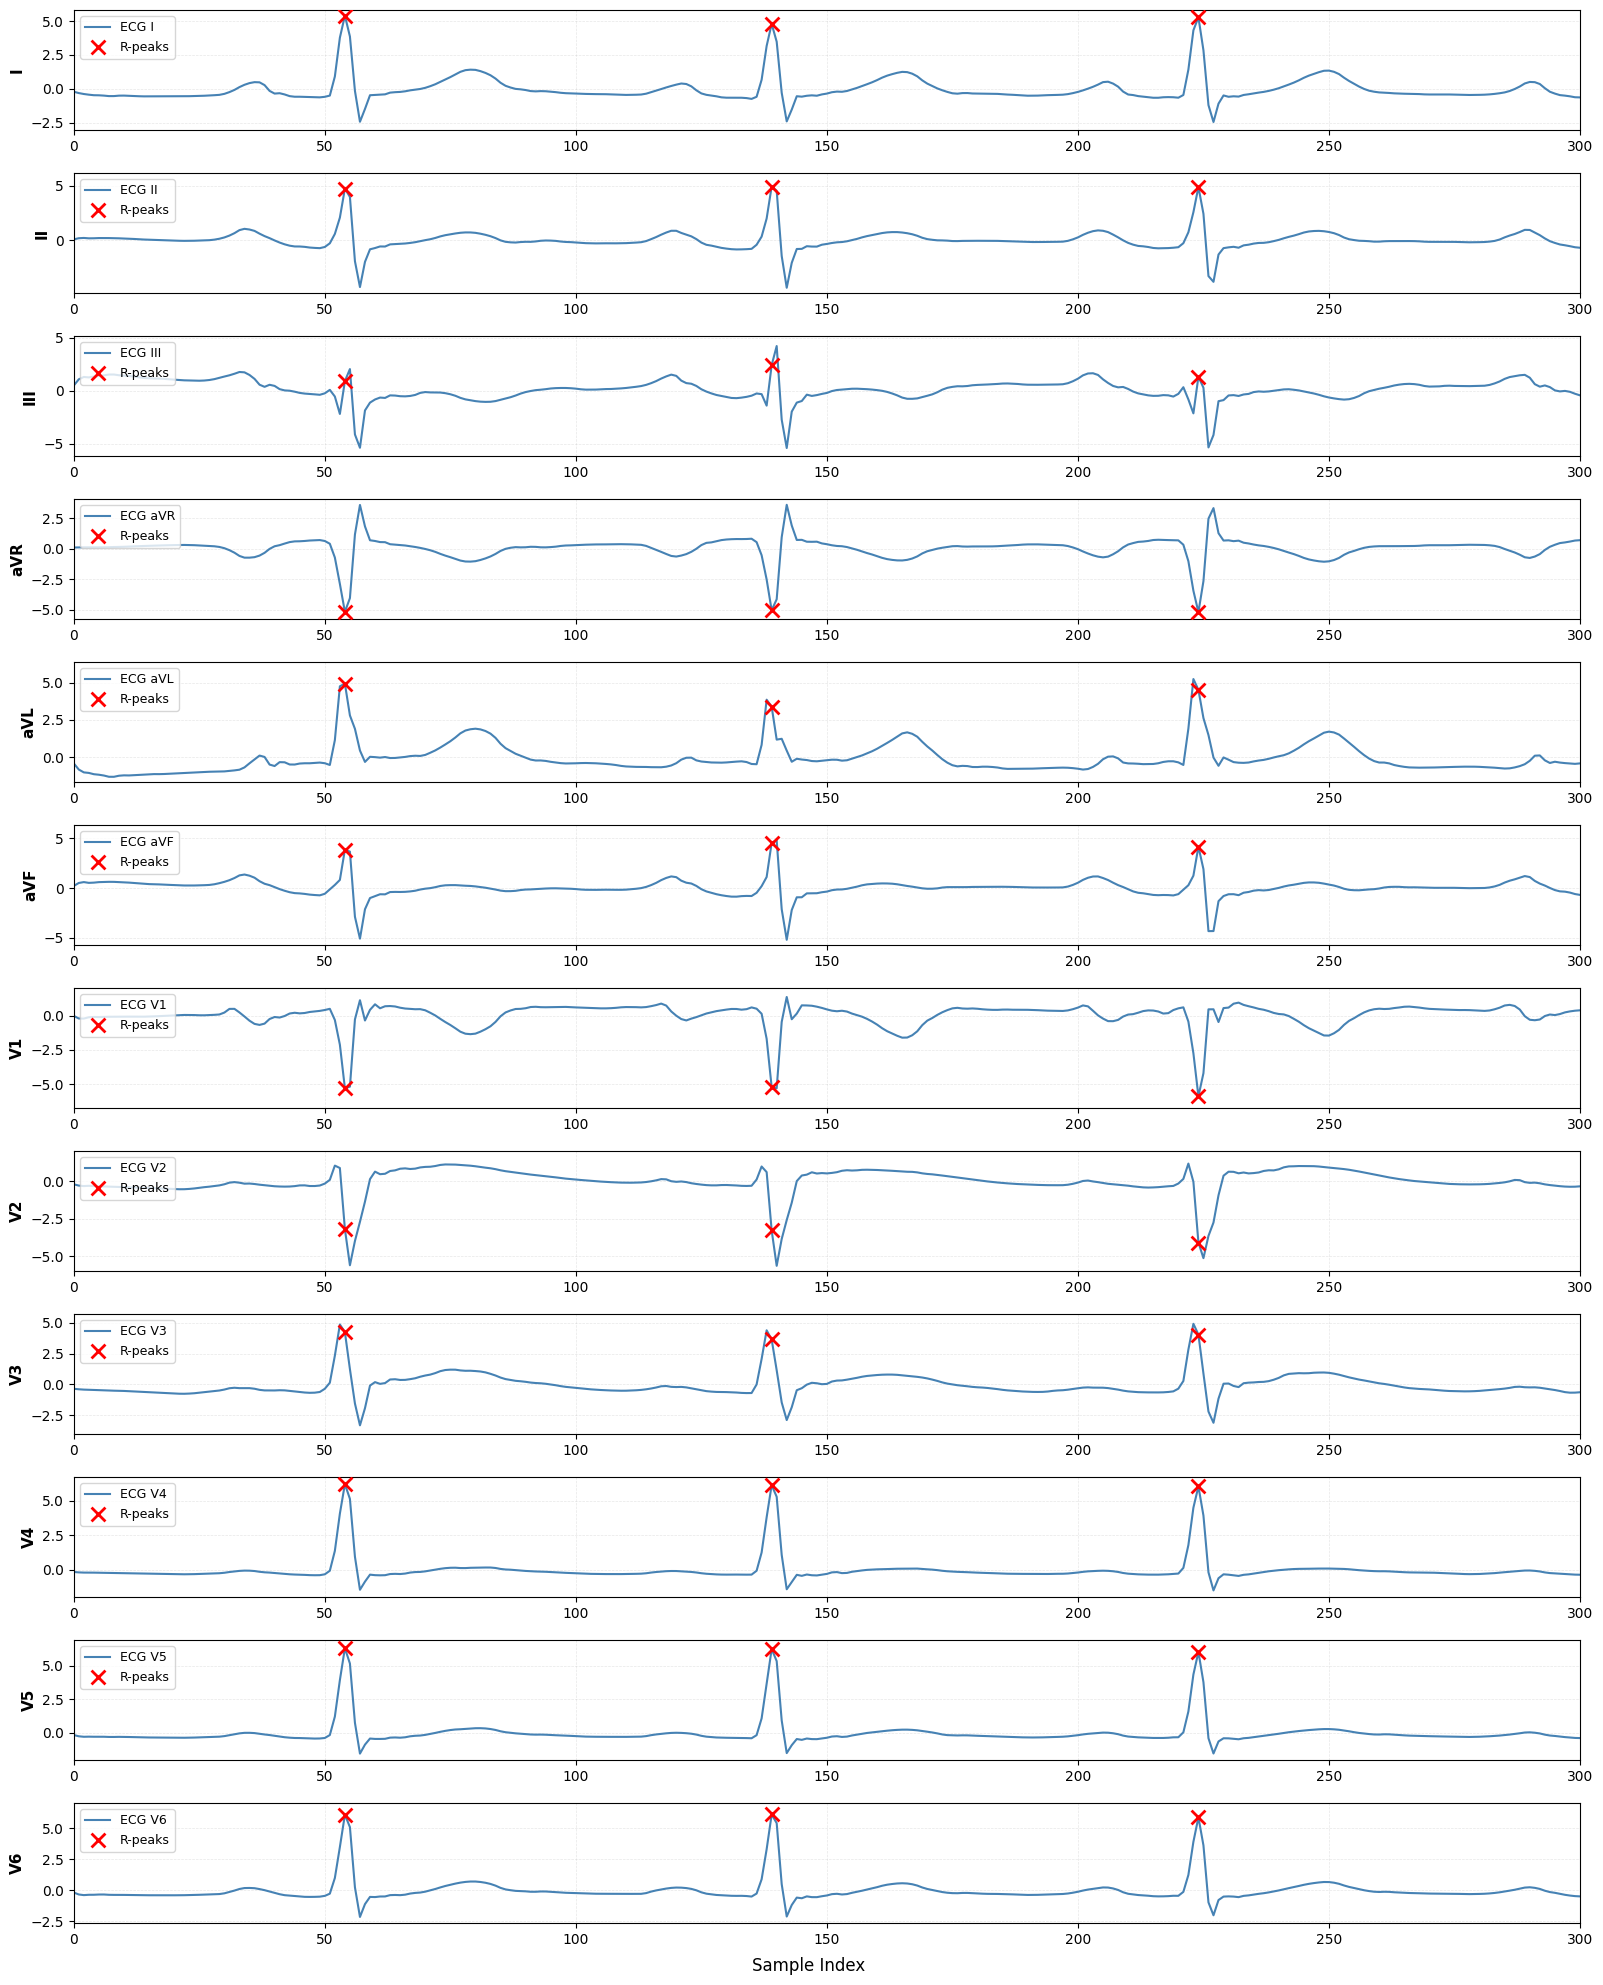

In [19]:
fig, axes = plt.subplots(12, 1, figsize=(16, 20))

for i, lead_name in enumerate(lead_names):
  signal = signals_clean[:, i]
  # Plot signal
  axes[i].plot(signal, linewidth=1.5, color='steelblue', label=f'ECG {lead_name}')
    # Plot R-peaks
  axes[i].scatter(r_peaks, signal[r_peaks], color='red', s=100, marker='x', linewidth=2, label='R-peaks', zorder=5)
    # Format
  axes[i].set_ylabel(lead_name, fontsize=11, fontweight='bold')
  axes[i].set_xlim(0, 300)
  axes[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
  axes[i].legend(loc='upper left', fontsize=9)

# Labels
fig.supxlabel('Sample Index', fontsize=12)

plt.tight_layout()
plt.show()

### 3.3 ST Feature Extraction 

In [20]:
def st_segment_features(signal: np.ndarray, fs: float = 100.0):
  """
  BEST: Combine timing from Function 2 + output from Function 1
  """
  
  leads_of_interest = [6, 7, 8]  # V1, V2, V3
  st_features = []
  
  r_peaks = detect_r_peaks(signal[:, 1], fs)
  
  if len(r_peaks) < 3:
    return np.zeros(6, dtype=np.float32)
  
  for lead_idx in leads_of_interest:
    lead = signal[:, lead_idx]
    st_values = []
    
    for r_peak in r_peaks:
      pr_start = max(0, r_peak - int(0.2 * fs))
      pr_end = max(0, r_peak - int(0.04 * fs))
      
      if pr_start >= pr_end:
        continue
      
      baseline = np.mean(lead[pr_start:pr_end])
      
      # ✓ CORRECT ST measurement (from Function 2)
      j_idx = r_peak + int(0.04 * fs)
      st_end = min(len(lead), r_peak + int(0.08 * fs))
      
      if j_idx < st_end <= len(lead):
        # Average ST segment 40-80ms
        st_point = np.mean(lead[j_idx:st_end])
        st_val = st_point - baseline
        st_values.append(st_val)
    
    if len(st_values) > 0:
      st_features.extend([
        np.mean(st_values),
        np.std(st_values),
      ])
    else:
      st_features.extend([0.0, 0.0, 0.0])
  
  return np.array(st_features, dtype=np.float32)

In [21]:
def st_morphology_features(signal: np.ndarray, fs: float = 100.0):
  """
  Extract ST segment shape (coved vs saddleback).
  
  Brugada features:
  - Coved: rapid rise then fall
  - Saddleback: dip then rise
  
  Returns: [ST_V1_slope, ST_V1_concavity, ST_V2_slope, ST_V2_curvature]
  """
  r_peaks = detect_r_peaks(signal[:, 1], fs)
  
  if len(r_peaks) < 3:
    return np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)
  
  features = []
  
  for lead_idx in [6, 7]:  # V1, V2 (most diagnostic)
    lead = signal[:, lead_idx]
    slopes = []
    curvatures = []
    
    for r in r_peaks:
      # ST segment window (40-200ms after R)
      st_start = r + int(0.04 * fs)
      st_end = r + int(0.2 * fs)
      
      if st_start >= st_end or st_end > len(lead):
        continue
      
      st_segment = lead[st_start:st_end]
      
      if len(st_segment) < 3:
        continue
      
      # Early slope (first 60ms)
      early_slope = (st_segment[len(st_segment)//2] - st_segment[0]) / (len(st_segment)//2)
      slopes.append(early_slope)
      
      # Curvature (concavity): second derivative
      if len(st_segment) >= 3:
        d1 = np.diff(st_segment)
        d2 = np.diff(d1)
        concavity = np.mean(d2) if len(d2) > 0 else 0.0
        curvatures.append(concavity)
    
    if slopes:
      features.append(np.mean(slopes))
    else:
      features.append(0.0)
    
    if curvatures:
      features.append(np.mean(curvatures))
    else:
      features.append(0.0)
  
  return np.array(features, dtype=np.float32)

### 3.5 Extract features

In [22]:
def extract_features(signal: np.ndarray, fs: float = 100.0) -> np.ndarray:
  st = st_segment_features(signal, fs)
  st_morph = st_morphology_features(signal, fs)
  time_domain = time_domain_features(signal)
  
  features = np.concatenate([
    st,             # 6 features
    st_morph,       # 4 features
    time_domain, 
  ], axis=0)

  return features

In [23]:
signal_temp = signals_clean # (1200, 12)

features = extract_features(signal_temp, fs=sampling_freq)
print("feature length:", len(features))
print(features)

feature length: 46
[ 3.1480333e-01  7.3970743e-02  3.6664346e-01  1.3767377e-01
  1.8732825e-01  1.3582832e-01  9.4248690e-02 -7.5252563e-02
  1.7537370e-01 -7.6299399e-02  8.8817840e-18  1.0000000e+00
  1.0000000e+00  7.4014872e-18  1.0000000e+00  1.0000000e+00
  1.7763568e-17  1.0000000e+00  1.0000000e+00 -7.4014872e-18
  1.0000000e+00  1.0000000e+00  1.4802974e-18  1.0000000e+00
  1.0000000e+00  2.2204460e-18  1.0000000e+00  1.0000000e+00
  1.4802974e-17  1.0000000e+00  1.0000000e+00  0.0000000e+00
  1.0000000e+00  1.0000000e+00  5.9211896e-18  1.0000000e+00
  1.0000000e+00 -5.1810408e-18  1.0000000e+00  1.0000000e+00
 -5.9211896e-18  1.0000000e+00  1.0000000e+00 -7.4014872e-18
  1.0000000e+00  1.0000000e+00]


In [24]:
def build_feature_matrix(X: np.ndarray, fs: float = 100) -> np.ndarray:
  """
  Extract features for every recording in the dataset.

  Parameters
  ----------
  X : np.ndarray, shape (N, N_SAMPLES, 12)

  Returns
  -------
  F : np.ndarray, shape (N, 123)
  """
  features = []
  for i in tqdm(range(X.shape[0]), desc="Extracting features"):
      features.append(extract_features(X[i], fs))
  return np.stack(features, axis=0)

#### Load All Dataset

In [25]:
metadata = pd.read_csv('metadata.csv')
metadata.head()

,patient_id,basal_pattern,sudden_death,brugada
0,188981,1,0,1
1,251972,0,0,0
2,265715,0,0,0
3,267628,0,0,0
4,267630,0,0,1


In [26]:
from tqdm import tqdm
import os

DATA_PATH = "./files"

def get_patient_dirs(data_path):
  """Get sorted list of patient directories"""
  dirs = []
  for dir in os.listdir(data_path):
    if os.path.isdir(os.path.join(data_path, dir)):
      dirs.append(dir)

  return sorted(dirs)

def get_hea_file(patient_path):
  """Find .hea file in patient directory"""
  for hea_file in os.listdir(patient_path):
    if hea_file.endswith('.hea'):
      return hea_file
  return None

def load_record(file_path):
  """Load single ECG record"""
  return wfdb.rdrecord(file_path)


def load_ecg_dataset(data_path):
  patient_dirs = get_patient_dirs(data_path)

  signals = []
  patient_ids = []
  labels = []
  lead_names = None
  sampling_freq = None

  meta_dict = dict(zip(metadata['patient_id'].astype(str), metadata['brugada']))

  for patient_id in tqdm(patient_dirs):

    if patient_id not in meta_dict:
      continue

    patient_path = os.path.join(data_path, patient_id)
    hea_file = get_hea_file(patient_path)
    
    if not hea_file:
      continue

    try:
      file_path = os.path.join(patient_path, hea_file[:-4])
      record = load_record(file_path)

      signals.append(record.p_signal)
      patient_ids.append(patient_id)
      labels.append(meta_dict[patient_id])

      if lead_names is None:
        lead_names = list(record.sig_name)
        sampling_freq = record.fs

    except Exception as e:
      print(f"Error {patient_id}: {e}")
    
  X = np.array(signals)
  y = np.array(labels)
  
  return X, y, np.array(patient_ids), lead_names, sampling_freq

In [27]:
X_raw, y, patient_ids, lead_names, fs = load_ecg_dataset(DATA_PATH)
print(f"X shape: {X_raw.shape}")
print(f"y shape: {y.shape}")

100%|██████████| 363/363 [00:00<00:00, 519.38it/s]

X shape: (363, 1200, 12)
y shape: (363,)


#### Check number of samples in each class

In [28]:
n_negative = int((y == 0).sum())
n_positive = int((y > 0).sum())

In [29]:
# Convert target to binary (0 or 1)
y = (y > 0).astype(int)

In [30]:
print(f"Negative {n_negative}, Positive {n_positive}")

Negative 287, Positive 76


In [31]:
X_clean = preprocess_dataset(X_raw)

100%|██████████| 363/363 [00:04<00:00, 81.93it/s]


In [32]:
X_features = build_feature_matrix(X_clean)
print(f'Feature matrix shape: {X_features.shape}')

Extracting features: 100%|██████████| 363/363 [00:00<00:00, 440.86it/s]

Feature matrix shape: (363, 46)


In [33]:
print(np.std(X_features, axis=0))

[7.08908439e-01 2.00057521e-01 7.02150583e-01 2.14842141e-01
 5.88412523e-01 1.69053271e-01 1.74850821e-01 5.06334417e-02
 1.61898986e-01 4.25001457e-02 1.16550121e-17 0.00000000e+00
 0.00000000e+00 1.07788896e-17 0.00000000e+00 0.00000000e+00
 1.08730857e-17 0.00000000e+00 0.00000000e+00 1.05724394e-17
 0.00000000e+00 0.00000000e+00 1.09634204e-17 0.00000000e+00
 0.00000000e+00 1.02810857e-17 0.00000000e+00 0.00000000e+00
 9.67475490e-18 0.00000000e+00 0.00000000e+00 1.07318289e-17
 0.00000000e+00 0.00000000e+00 1.18338253e-17 0.00000000e+00
 0.00000000e+00 1.07953431e-17 0.00000000e+00 0.00000000e+00
 9.68863499e-18 0.00000000e+00 0.00000000e+00 9.21964757e-18
 0.00000000e+00 0.00000000e+00]


In [34]:
def make_feature_names(lead_names):
  """Create feature names for all extracted features"""
  
  # Time-domain features (all 12 leads)
  time_domain_features = []
  for lead_name in lead_names:
    time_domain_features += [f"{lead_name}_mean", f"{lead_name}_std", f"{lead_name}_rms"]
  
  # ST Segment features (V1, V2, V3 only)
  st_elevation_features = []
  for lead_name in ['V1', 'V2', 'V3']:
    st_elevation_features += [f"ST_{lead_name}_mean", f"ST_{lead_name}_std"]
  
  st_morph_features = []
  for lead_name in ['V1', 'V2']:
    st_morph_features += [f"ST_{lead_name}_slope", f"ST_{lead_name}_curvature"]
  
  feature_names = (st_elevation_features + st_morph_features + time_domain_features)
  
  print(f"Total features: {len(feature_names)}")
  return feature_names

In [35]:
X_features.shape

(363, 46)

In [36]:
feature_names = make_feature_names(lead_names)
print(len(feature_names))

Total features: 46
46


In [37]:
features_df = pd.DataFrame(X_features, columns=feature_names)
features_df['label'] = y 

In [38]:
positive_samples = features_df.query("label > 0")
positive_samples

,ST_V1_mean,ST_V1_std,ST_V2_mean,ST_V2_std,ST_V3_mean,ST_V3_std,ST_V1_slope,ST_V1_curvature,ST_V2_slope,ST_V2_curvature,...,V4_mean,V4_std,V4_rms,V5_mean,V5_std,V5_rms,V6_mean,V6_std,V6_rms,label
16,1.836525,0.122140,1.826594,0.194427,-0.223048,0.154066,-0.194506,-0.022640,0.075407,-0.081873,...,-7.401487e-18,1.0,1.0,1.184238e-17,1.0,1.0,-1.480297e-18,1.0,1.0,1
22,1.584840,0.900230,0.718496,0.983261,-0.915655,0.748210,-0.000623,-0.026210,0.103044,-0.053399,...,8.881784e-18,1.0,1.0,0.000000e+00,1.0,1.0,4.810966e-18,1.0,1.0,1
26,0.967330,0.741522,1.992006,1.327201,0.795913,0.076749,-0.064786,0.005657,-0.158200,0.013818,...,7.401487e-18,1.0,1.0,0.000000e+00,1.0,1.0,2.220446e-18,1.0,1.0,1
35,1.537905,0.126351,1.153389,0.295725,-0.251437,0.292251,-0.136339,-0.046348,0.112887,-0.077156,...,-5.921190e-18,1.0,1.0,-2.220446e-18,1.0,1.0,7.401487e-18,1.0,1.0,1
38,0.635833,0.230153,0.785824,0.185215,-0.248190,0.051246,0.154292,-0.049931,0.208971,-0.052183,...,-1.480297e-17,1.0,1.0,0.000000e+00,1.0,1.0,-1.480297e-17,1.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,1.568635,0.209215,2.115680,0.214178,1.344315,0.220321,-0.072343,-0.018211,-0.111908,-0.010539,...,-7.401487e-18,1.0,1.0,3.700744e-18,1.0,1.0,1.258253e-17,1.0,1.0,1
351,0.404747,0.391398,0.408365,0.379993,-0.020217,0.244187,0.123812,-0.074400,0.142826,-0.048342,...,1.184238e-17,1.0,1.0,2.960595e-18,1.0,1.0,-1.480297e-18,1.0,1.0,1
352,0.951618,0.080624,2.350670,0.173941,1.120291,0.168733,-0.019390,-0.043845,-0.200838,-0.045681,...,-1.887379e-17,1.0,1.0,-2.960595e-17,1.0,1.0,-1.480297e-18,1.0,1.0,1
354,1.866027,0.111212,1.991152,0.178674,0.524671,0.082984,-0.249443,-0.012947,-0.065398,-0.029520,...,5.551115e-18,1.0,1.0,9.251859e-18,1.0,1.0,5.551115e-18,1.0,1.0,1


In [39]:
features_df.to_csv('features_file.csv', index=False)